# CPW Microwave Drive Model for NV Centers

This notebook models a coplanar waveguide (CPW) used to drive NV centers with microwaves. It explores how geometry and distance affect: magnetic field strength (B1), required current, required microwave power, and resistive heating at cryogenic temperatures.

The physics model uses simple analytical approximations valid for near-field CPW drive conditions. The notebook includes plots of B1 vs current, required current vs Rabi frequency, power vs distance/width, RF resistance, dissipated power, and drive efficiency.

TO DO
-mu_0 in skindpeth is also dependent on mu_r ofc. Check to make sure final model is okay
-Check which length to use for resistance
-Check correct resistivity of copper at Cryo

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import EngFormatter
from matplotlib.patches import Rectangle
from scipy.optimize import curve_fit


sns.set_theme(context='notebook', style='darkgrid', palette='Set1')
sns.color_palette("Paired")
plt.rcParams.update({'font.size': 12})

In [3]:
# Physical constants
mu0 = 4 * np.pi * 1e-7  # vacuum permeability [H/m]
Z0 = 50.0  # characteristic impedance [ohm] for the transmission line
gamma_e = 28e9  # electron gyromagnetic ratio [Hz/T] for NV centers

# Resistivities
rho_RT = 1.7e-8  # room temperature copper resistivity [ohm*m]
rho_cryo = 1.7e-10  # conservative cryogenic copper resistivity [ohm*m]
#rho_cryo = 2e-11  # conservative cryogenic copper resistivity [ohm*m]

# Frequency ranges
f_nv = 2.87e9  # main NV frequency [Hz]
f_sweep = np.linspace(2e9, 6e9, 401)  # frequency sweep [Hz]
omega_sweep = 2 * np.pi * f_sweep  # angular frequency [rad/s]

# CPW geometry
distances = np.array([1e-6, 10e-6, 50e-6, 100e-6, 200e-6])  # distance from CPW to NV [m]
distances_continous = np.linspace(1e-6, 200e-6, 50)  # for continuous plots
widths = np.array([2e-3, 1e-3, 0.5e-3, 0.2e-3])  # center conductor width w [m]
gaps = np.array([55e-5, 17e-5, 85e-6, 48.5e-6])    # gap to ground planes s [m]
thickness = 18e-6  # copper thickness [m]
length = 37e-3  # trace length [m]
straight_length = 19.2e-3  # length of straight section near NV [m]

# Derived helper functions
def b1_from_current(I, r):
    """Magnetic field amplitude from a straight conductor approximation."""
    return mu0 * I / (2 * np.pi * r)

def b1_from_current_cpw(I, r, w):
    """Magnetic field amplitude from a square waveguide approximation."""
    return mu0 * I / (np.pi * w) * np.arctan(w / (2 * r))
    

def current_for_rabi(Omega, r):
    """Current required to achieve Rabi frequency Omega at distance r."""
    B1_required = Omega / gamma_e
    return 2 * np.pi * r * B1_required / mu0

def current_for_rabi_cpw(Omega, r, w):
    """
    Current required to achieve Rabi frequency Omega at distance r 
    for a strip of width w.
    """
    B1_required = Omega / gamma_e
    return B1_required * np.pi * w / (mu0 * np.arctan(w / (2 * r)))

def power_from_current(I):
    """Power delivered into a 50 ohm line for peak current I."""
    return I**2 * Z0   # I is RMS

def normal_resistance(rho, width, thickness):
    """DC-like resistance (valid approximation for RT). Uses full cross-section A = w * t."""
    A = width * thickness
    return rho * length / A

def skin_depth(rho, omega):
    """Calculate skin depth delta for given resistivity rho and driving frequency omega."""
    return np.sqrt(2 * rho / (omega * mu0))

def rf_resistance(rho, width, thickness, omega):
    """RF resistance using skin depth (cryo regime). Current flows in surface layer of thickness delta."""
    delta = skin_depth(rho, omega)
    return rho * length / (2 * (width + thickness) * np.maximum(delta, 1e-12))

def dissipated_power(I, R):
    return I**2 * R

## 1. Magnetic field strength B1 vs current (infinitly thin and long wire)

Plot B1 as a function of current for several distances from the CPW. This shows the strong distance dependence of the near-field microwave drive.

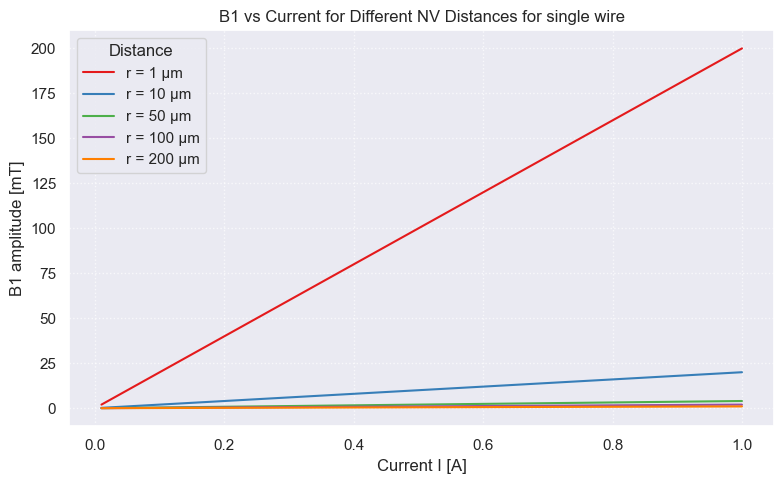

In [4]:

I_values = np.linspace(0.01, 1.0, 200)  # current range [A]
plt.figure(figsize=(8, 5))
for i, r in enumerate(distances):
    plt.plot(I_values, b1_from_current(I_values, r) * 1e3, label=f'r = {r*1e6:.0f} µm')

plt.xlabel('Current I [A]')
plt.ylabel('B1 amplitude [mT]')
plt.title('B1 vs Current for Different NV Distances for single wire')
plt.legend(title='Distance')
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

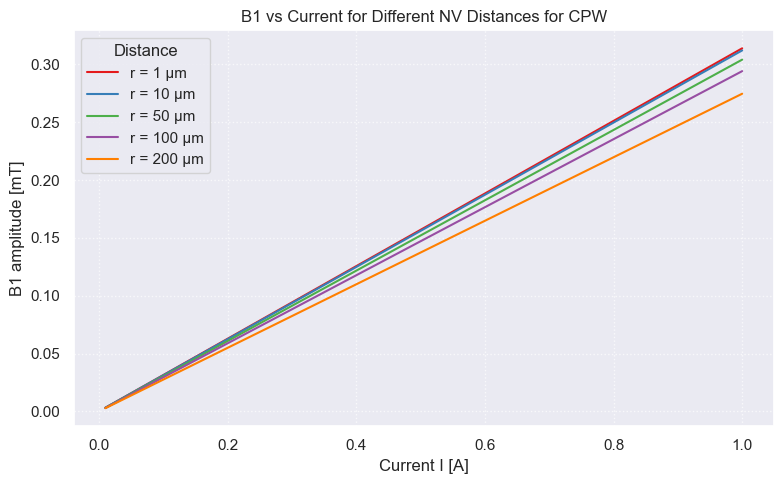

In [5]:
I_values = np.linspace(0.01, 1.0, 200)  # current range [A]
plt.figure(figsize=(8, 5))
for i, r in enumerate(distances):
    plt.plot(I_values, b1_from_current_cpw(I_values, r, widths[0]) * 1e3, label=f'r = {r*1e6:.0f} µm')

plt.xlabel('Current I [A]')
plt.ylabel('B1 amplitude [mT]')
plt.title('B1 vs Current for Different NV Distances for CPW')
plt.legend(title='Distance')
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

## 2. Required current vs Rabi frequency

Compute the current needed to generate Rabi frequencies between 1 and 20 MHz at each geometric distance.

10 MHz required current at r=1 µm: 0.002 A
10 MHz required current at r=10 µm: 0.018 A
10 MHz required current at r=50 µm: 0.089 A
10 MHz required current at r=100 µm: 0.179 A
10 MHz required current at r=200 µm: 0.357 A


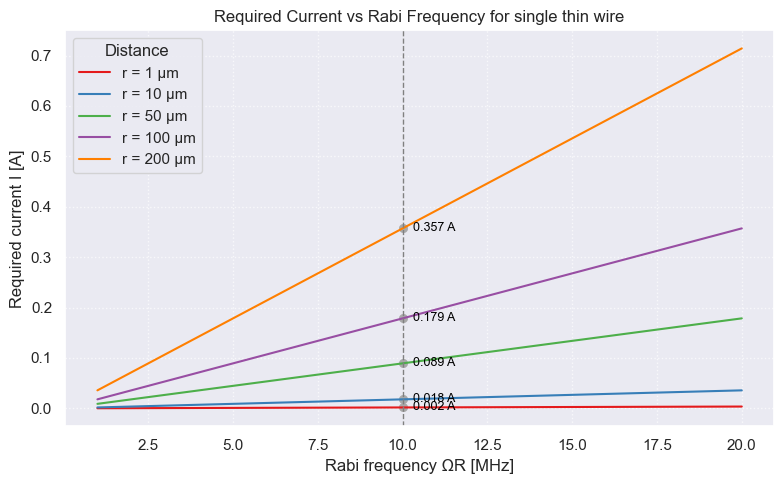

In [6]:
Omega_range = np.linspace(1e6, 20e6, 200)  # Rabi frequencies [Hz]
fixed_rabi_line = 10e6  # highlight 10 MHz

plt.figure(figsize=(8, 5))
for r in distances:
    I_req = current_for_rabi(Omega_range, r)
    plt.plot(Omega_range * 1e-6, I_req, label=f'r = {r*1e6:.0f} µm')

# Draw a vertical line at 10 MHz and label its current values
plt.axvline(fixed_rabi_line * 1e-6, color='gray', linestyle='--', linewidth=1)
for r in distances:
    I_10MHz = current_for_rabi(fixed_rabi_line, r)
    plt.scatter([fixed_rabi_line * 1e-6], [I_10MHz], color='darkgray', linewidth=0.5, zorder=1)
    plt.text(
        fixed_rabi_line * 1e-6 + 0.3,
        I_10MHz,
        f'{I_10MHz:.3f} A',
        va='center',
        fontsize=9,
        color='black'
    )
    print(f'10 MHz required current at r={r*1e6:.0f} µm: {I_10MHz:.3f} A')

plt.xlabel('Rabi frequency ΩR [MHz]')
plt.ylabel('Required current I [A]')
plt.title('Required Current vs Rabi Frequency for single thin wire')
plt.legend(title='Distance')
plt.yscale('linear')
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

10 MHz required current at r=1 µm: 1.138 A
10 MHz required current at r=10 µm: 1.144 A
10 MHz required current at r=50 µm: 1.174 A
10 MHz required current at r=100 µm: 1.214 A
10 MHz required current at r=200 µm: 1.300 A


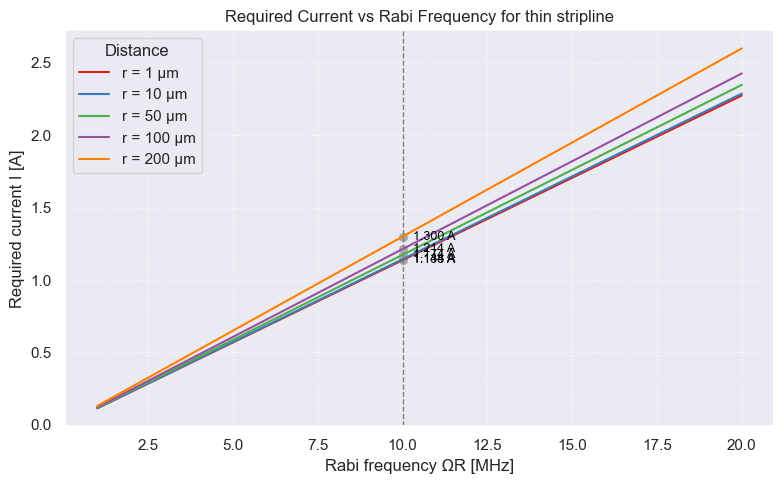

In [7]:
###### 2.2 CPW model Rabi

Omega_range = np.linspace(1e6, 20e6, 200)  # Rabi frequencies [Hz]
fixed_rabi_line = 10e6  # highlight 10 MHz

plt.figure(figsize=(8, 5))
for r in distances:
    I_req = current_for_rabi_cpw(Omega_range, r, widths[0])
    plt.plot(Omega_range * 1e-6, I_req, label=f'r = {r*1e6:.0f} µm')

# Draw a vertical line at 10 MHz and label its current values
plt.axvline(fixed_rabi_line * 1e-6, color='gray', linestyle='--', linewidth=1)
for r in distances:
    I_10MHz = current_for_rabi_cpw(fixed_rabi_line, r, widths[0])
    plt.scatter([fixed_rabi_line * 1e-6], [I_10MHz], color='darkgray', linewidth=0.5, zorder=1)
    plt.text(
        fixed_rabi_line * 1e-6 + 0.3,
        I_10MHz,
        f'{I_10MHz:.3f} A',
        va='center',
        fontsize=9,
        color='black'
    )
    print(f'10 MHz required current at r={r*1e6:.0f} µm: {I_10MHz:.3f} A')

plt.xlabel('Rabi frequency ΩR [MHz]')
plt.ylabel('Required current I [A]')
plt.title('Required Current vs Rabi Frequency for thin stripline')
plt.legend(title='Distance')
plt.yscale('linear')
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

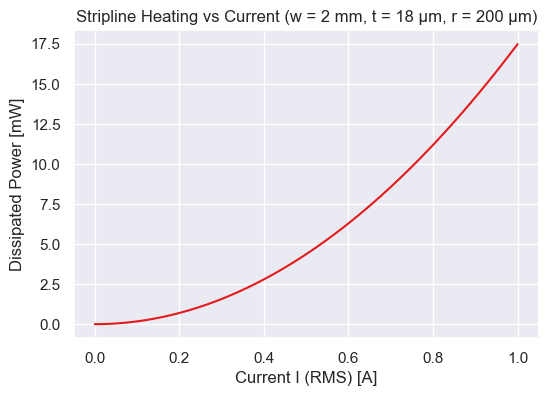

Resistance at RT with these dimensions: 1.7472e-02 ohm


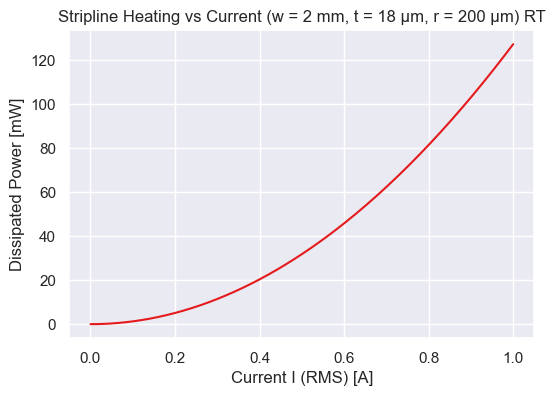

Skin depth at 2.87 GHz: 1.22 µm, and resistance at RT: 1.2723e-01 ohm


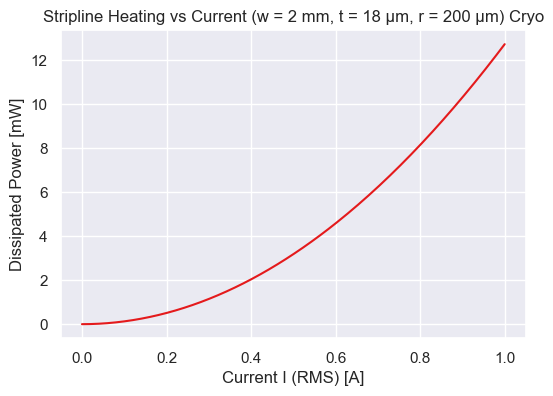

Skin depth at 2.87 GHz: 0.12 µm, and resistance at cryo: 1.2723e-02 ohm


In [8]:
# --- Fixed parameters ---
w = 2e-3          # 2 mm strip width
thickness = 18e-6 # 18 µm copper thickness
r = 200e-6        # 200 µm distance
f = f_nv          # 2.87 GHz
omega = 2 * np.pi * f

I_vals = np.linspace(0, 1.0, 200)

R_normal = normal_resistance(rho_RT, w, thickness)

P_heat = dissipated_power(I_vals, R_normal)

plt.figure(figsize=(6,4))
plt.plot(I_vals, P_heat * 1e3)  # convert to mW for better readability
plt.xlabel("Current I (RMS) [A]")
plt.ylabel("Dissipated Power [mW]")
plt.title("Stripline Heating vs Current (w = 2 mm, t = 18 µm, r = 200 µm)")
plt.grid(True)
plt.show()

print(f"Resistance at RT with these dimensions: {R_normal:.4e} ohm")

R_RT = rf_resistance(rho_RT, w, thickness, omega)

P_heat_RT = dissipated_power(I_vals, R_RT)

plt.figure(figsize=(6,4))
plt.plot(I_vals, P_heat_RT * 1e3)  # convert to mW for better readability
plt.xlabel("Current I (RMS) [A]")
plt.ylabel("Dissipated Power [mW]")
plt.title("Stripline Heating vs Current (w = 2 mm, t = 18 µm, r = 200 µm) RT")
plt.grid(True)
plt.show()

print(f"Skin depth at 2.87 GHz: {skin_depth(rho_RT, omega)*1e6:.2f} µm, and resistance at RT: {R_RT:.4e} ohm")


R_cryo = rf_resistance(rho_cryo, w, thickness, omega)

P_heat_cryo = dissipated_power(I_vals, R_cryo)

plt.figure(figsize=(6,4))
plt.plot(I_vals, P_heat_cryo * 1e3)  # convert to mW for better readability
plt.xlabel("Current I (RMS) [A]")
plt.ylabel("Dissipated Power [mW]")
plt.title("Stripline Heating vs Current (w = 2 mm, t = 18 µm, r = 200 µm) Cryo")
plt.grid(True)
plt.show()

print(f"Skin depth at 2.87 GHz: {skin_depth(rho_cryo, omega)*1e6:.2f} µm, and resistance at cryo: {R_cryo:.4e} ohm")

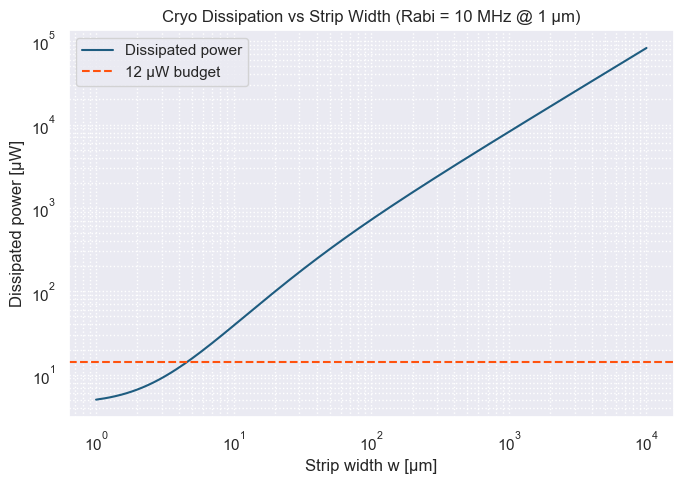

Maximum width satisfying cryo budget: 4.40 µm


In [12]:
Omega_target = 10e6         # Rabi frequency
r = 1e-6                    # NV depth
thickness = 18e-6           # copper thickness
f = f_nv                    # driving frequency
omega = 2*np.pi*f

P_cooling = 14e-6           # cooling power

w_vals = np.logspace(-6, -2, 200)  

I_req = current_for_rabi_cpw(Omega_target, r, w_vals)

R_vals = rf_resistance(rho_cryo, w_vals, thickness, omega)

P_vals = dissipated_power(I_req, R_vals)

plt.figure(figsize=(7,5))
plt.loglog(w_vals*1e6, P_vals*1e6, label="Dissipated power", color="#1E5C80")

plt.axhline(P_cooling*1e6, color="#FF520E", linestyle='--', label="12 µW budget")

plt.xlabel("Strip width w [µm]")
plt.ylabel("Dissipated power [µW]")
plt.title("Cryo Dissipation vs Strip Width (Rabi = 10 MHz @ 1 µm)")
plt.grid(True, which='both', linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()


valid = np.where(P_vals <= P_cooling)[0]

if len(valid) > 0:
    w_max = w_vals[valid[-1]]
    print(f"Maximum width satisfying cryo budget: {w_max*1e6:.2f} µm")
else:
    print("No width in tested range satisfies power constraint.")

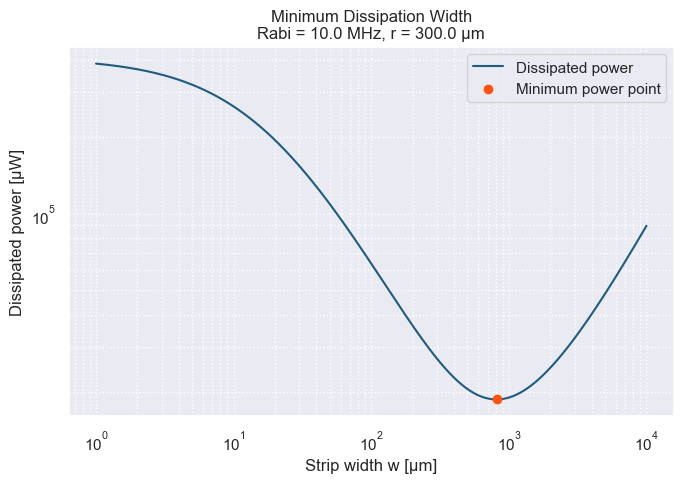

Optimal width        : 814.54 µm
Minimum dissipation  : 18621.92 µW


In [10]:
Omega_target = 10e6      # Target Rabi frequency [Hz]
r = 300e-6               # NV distance from strip [m]
thickness = 18e-6        # Copper thickness [m]
f = f_nv                 # Drive frequency [Hz]

# Width sweep
w_vals = np.logspace(-6, -2, 1000)

# Angular frequency
omega = 2 * np.pi * f

# Required current for each width
I_req = current_for_rabi_cpw(Omega_target, r, w_vals)

# RF resistance
R_vals = rf_resistance(rho_cryo, w_vals, thickness, omega)

# Dissipated power
P_vals = dissipated_power(I_req, R_vals)

idx_min = np.argmin(P_vals)

w_opt = w_vals[idx_min]
P_min = P_vals[idx_min]

plt.figure(figsize=(7,5))

plt.loglog(
    w_vals * 1e6,
    P_vals * 1e6,
    color="#1E5C80",
    label="Dissipated power"
)

plt.scatter(
    w_opt * 1e6,
    P_min * 1e6,
    color="#FF520E",
    zorder=5,
    label="Minimum power point"
)

plt.xlabel("Strip width w [µm]")
plt.ylabel("Dissipated power [µW]")

plt.title(
    f"Minimum Dissipation Width\n"
    f"Rabi = {Omega_target*1e-6:.1f} MHz, r = {r*1e6:.1f} µm"
)

plt.grid(True, which='both', linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()


print(f"Optimal width        : {w_opt*1e6:.2f} µm")
print(f"Minimum dissipation  : {P_min*1e6:.2f} µW")

Fitted parameters: a = 0.03908, n = 2.005
Estimated cooling power at 350 mK: 4919.88 µW


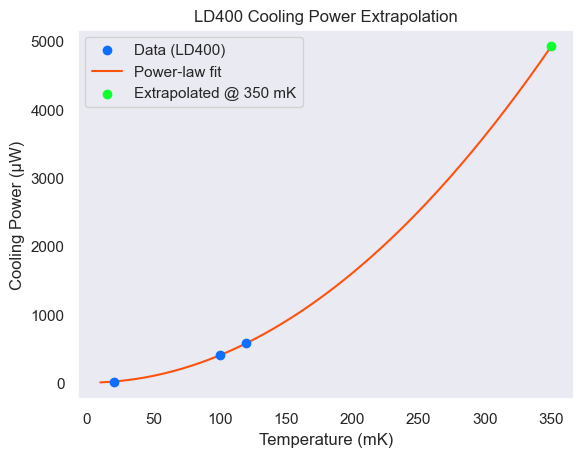

In [18]:
# Data for LD400 (Temperature in mK, Power in µW)
T = np.array([20, 100, 120])
P = np.array([14, 400, 575])

# Power-law model
def model(T, a, n):
    return a * T**n

# Fit the curve
params, _ = curve_fit(model, T, P)
a, n = params

print(f"Fitted parameters: a = {a:.4g}, n = {n:.4g}")

# Generate smooth curve for plotting
T_fit = np.linspace(10, 350, 200)
P_fit = model(T_fit, a, n)

# Extrapolated point
T_target = 350
P_350 = model(T_target, a, n)

print(f"Estimated cooling power at {T_target} mK: {P_350:.2f} µW")

# Plot
plt.figure()
plt.scatter(T, P, label="Data (LD400)", color="#0E6EFF", zorder=3)
plt.plot(T_fit, P_fit, label="Power-law fit", color="#FF520E")
plt.scatter(T_target, P_350, color="#0EFF2E", label=f"Extrapolated @ 350 mK", zorder=2)

plt.xlabel("Temperature (mK)")
plt.ylabel("Cooling Power (µW)")
plt.title("LD400 Cooling Power Extrapolation")
plt.legend()
plt.grid()

plt.show()


In [ ]:
# Calculate temperature for a given cooling power (e.g., 18.6 mW = 18600 µW)
P_query = 18600  # µW
# Invert the model: T = (P/a)^(1/n)
T_query = (P_query / a) ** (1/n)
print(f"Expected temperature at {P_query/1000:.2f} mW cooling power: {T_query:.2f} mK")
T_query

Expected temperature at 18.60 mW cooling power: 679.48 mK


np.float64(679.4751353136113)

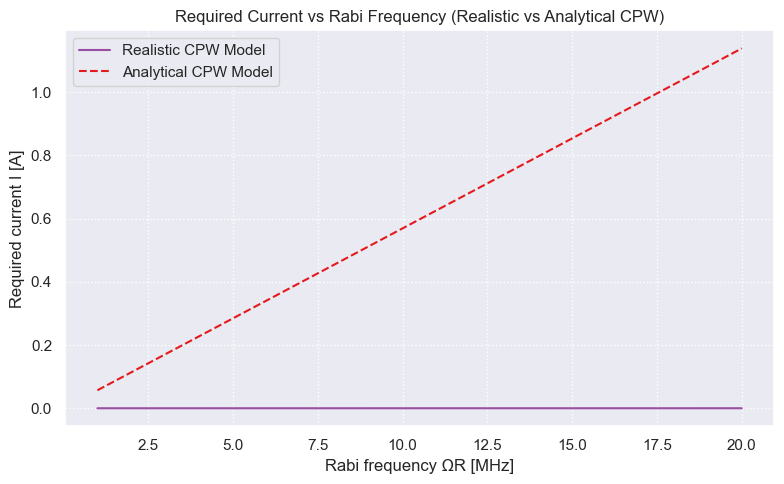

Required current at 10 MHz (realistic CPW): 0.0000 A
Required current at 10 MHz (analytical CPW): 0.5691 A


In [ ]:
# --- Comparison: Analytical vs Realistic CPW Magnetic Field Model ---
import types

def hx(x, y, width, height):
    return (1/(8*np.pi*width*height))*((width-x)*((1/2)*np.log(((height-y)**2+(width-x)**2)/((-height-y)**2+(width-x)**2))+((height-y)/(width-x))*np.arctan((width-x)/(height-y))-((-height-y)/(width-x))*np.arctan((width-x)/(-height-y)))-(-width-x)*((0.5*np.log(((height-y)**2+(-width-x)**2)/((-height-y)**2+(-width-x)**2)))+((height-y)/(-width-x))*np.arctan((-width-x)/(height-y))-((-height-y)/(-width-x))*np.arctan((-width-x)/(-height-y))))

def hy(x, y, width, height):
    return (1/(8*np.pi*width*height))*((height-y)*((1/2)*np.log(((height-y)**2+(width-x)**2)/((height-y)**2+(-width-x)**2))+((width-x)/(height-y))*np.arctan((height-y)/(width-x))-((-width-x)/(height-y))*np.arctan((height-y)/(-width-x)))-(-height-y)*((0.5*np.log(((-height-y)**2+(width-x)**2)/((-height-y)**2+(-width-x)**2)))+((width-x)/(-height-y))*np.arctan((-height-y)/(width-x))-((-width-x)/(-height-y))*np.arctan((-height-y)/(-width-x))))

def hx_CPW(x, y, height, I_in, Innerewidth, I_out, distance, outer_width):
    return I_in*hx(x, y, Innerewidth, height=height) + I_out*hx(x-distance-Innerewidth-outer_width, y, outer_width, height=height) + I_out*hx(x+distance+Innerewidth+outer_width, y, outer_width, height=height)

def hy_CPW(x, y, height, I_in, Innerewidth, I_out, distance, outer_width):
    return I_in*hy(x, y, Innerewidth, height) + I_out*hy(x-distance-Innerewidth-outer_width, y, outer_width, height) + I_out*hy(x+distance+Innerewidth+outer_width, y, outer_width, height)

# Parameters for realistic CPW
full_width = 2e-3  # 2 mm
inner_width = 1e-3 # 1 mm
outer_width = 1e-3 # 1 mm
gap = 0.55e-3      # 0.55 mm
distance = gap     # gap between center and ground
thickness = 18e-6  # 18 um
r = 1e-6           # NV depth (1 um)
height = thickness # use thickness as height

# Use the same Rabi frequency and gamma_e as before
Omega_target = 10e6
B1_required = Omega_target / gamma_e

# Required current for the realistic field at r (center)
def current_for_rabi_realistic(Omega, r, inner_width, outer_width, distance, height):
    x = 0
    y = -r
    def field_for_I(I):
        return np.abs(hx_CPW(x, y, height, I, inner_width, I, distance, outer_width))
    from scipy.optimize import root_scalar
    def eqn(I):
        return field_for_I(I) - (Omega / gamma_e)
    sol = root_scalar(eqn, bracket=[1e-6, 10], method='bisect')
    return sol.root if sol.converged else np.nan

# Sweep Rabi frequencies for comparison
Omega_range = np.linspace(1e6, 20e6, 100)
I_req_realistic = np.array([
    current_for_rabi_realistic(Omega, r, inner_width, outer_width, distance, height)
    for Omega in Omega_range
])

plt.figure(figsize=(8, 5))
plt.plot(Omega_range * 1e-6, I_req_realistic, label='Realistic CPW Model', color='C3')
I_req_analytical = current_for_rabi_cpw(Omega_range, r, inner_width)
plt.plot(Omega_range * 1e-6, I_req_analytical, '--', label='Analytical CPW Model', color='C0')
plt.xlabel('Rabi frequency ΩR [MHz]')
plt.ylabel('Required current I [A]')
plt.title('Required Current vs Rabi Frequency (Realistic vs Analytical CPW)')
plt.legend()
plt.grid(True, which='both', linestyle=':')
plt.tight_layout()
plt.show()

I_10MHz_real = current_for_rabi_realistic(10e6, r, inner_width, outer_width, distance, height)
I_10MHz_analytical = current_for_rabi_cpw(10e6, r, inner_width)
print(f"Required current at 10 MHz (realistic CPW): {I_10MHz_real:.4f} A")
print(f"Required current at 10 MHz (analytical CPW): {I_10MHz_analytical:.4f} A")

# --- Power dissipation comparison ---
# Use the realistic current for power dissipation calculation
f = f_nv
omega = 2 * np.pi * f

R_cryo_real = rf_resistance(rho_cryo, inner_width, thickness, omega)
P_diss_real = I_10MHz_real**2 * R_cryo_real

R_cryo_analytical = rf_resistance(rho_cryo, inner_width, thickness, omega)
P_diss_analytical = I_10MHz_analytical**2 * R_cryo_analytical

print(f"Power dissipation at 10 MHz (realistic CPW): {P_diss_real*1e6:.4f} µW")
print(f"Power dissipation at 10 MHz (analytical CPW): {P_diss_analytical*1e6:.4f} µW")

# Plot power dissipation vs Rabi frequency for both models
P_diss_realistic = I_req_realistic**2 * R_cryo_real
P_diss_analytical = I_req_analytical**2 * R_cryo_analytical

plt.figure(figsize=(8, 5))
plt.plot(Omega_range * 1e-6, P_diss_realistic * 1e6, label='Realistic CPW Model', color='C3')
plt.plot(Omega_range * 1e-6, P_diss_analytical * 1e6, '--', label='Analytical CPW Model', color='C0')
plt.xlabel('Rabi frequency ΩR [MHz]')
plt.ylabel('Power dissipation [µW]')
plt.title('Power Dissipation vs Rabi Frequency (Realistic vs Analytical CPW)')
plt.legend()
plt.grid(True, which='both', linestyle=':')
plt.tight_layout()
plt.show()
